# 01 — Readout Calibration
Run after cooldown or if readout behaves unexpectedly.
Covers: TOF, resonator spectroscopy, chi to qubit, 2D gain sweep, single shot.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2')
sys.path.insert(1, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from meas_utils import MultimodeStation
from calibration_helpers import (
    init_helpers,
    do_tof, update_tof,
    do_res_spec, update_res_spec,
    do_single_shot, update_single_shot,
)

station = MultimodeStation(
    experiment_name  = '2600403_lmm',
    hardware_config  = 'hardware_config_20260111.yml',
)
init_helpers(station)
config_thisrun = station.config_thisrun
cfg_dict       = station.cfg_dict
meas           = station.meas
print('Station ready.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
connected proxies, ns= <Pyro4.core.Proxy at 0x1dbf106c450; connected IPv4; for PYRO:Pyro.NameServer@10.108.30.32:9090>
Path added at highest priority
['C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\_Lib\\python', 'C:\\_Lib\\python\\slab', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\python313.zip', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\DLLs', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib', 'c:\\ProgramData\\Anaconda3\\envs\\mm313', '', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib\\site-packages']
Experiments module p

## Time of Flight

In [ ]:
tof = do_tof(
    config_thisrun                = config_thisrun,
    reps                          = 1,
    rounds                        = 100,
    check_e                       = False,
    final_delay                   = 500,
    analyze_and_display           = True,
    use_config_params_for_readout = False,
    gain                          = 1.0,
    length                        = 3.0,
    frequency                     = config_thisrun.device.readout.frequency,
)

In [ ]:
# Read x-value where signal rises from the plot, then set new_trig_offset
update_tof(
    tof             = tof,
    config_thisrun  = config_thisrun,
    new_trig_offset = 0.5,   # <-- edit this
)

## Resonator Spectroscopy

In [14]:
config_thisrun.hw.soc.dacs.readout.fc = 6300
config_thisrun.hw.soc.dacs.readout.att = [10,0]
station.handle_config_update(True)

Comparing configurations:
Key 'hw.soc.dacs.readout.att' differs:
  Old value (config1): [30, 0]
  New value (config2): [10, 0]
Configuration updated and saved, excluding storage_man_file.


In [23]:
rspec = do_res_spec(
    config_thisrun                = config_thisrun,
    frequency                     = 6322.065,#config_thisrun.device.readout.frequency,
    span                          = 1,
    expts                         = 1000,
    reps                          = 200,
    rounds                        = 1,
    gain                          = 0.1, #config_thisrun.device.readout.gain,
    length                        = 1.0,# config_thisrun.device.readout.length,
    final_delay                   = 250,
    pulse_e                       = False,
    prepulse                      = {},
    analyze_and_display           = False,
    use_config_params_for_readout = False,
)

connected proxies, ns= <Pyro4.core.Proxy at 0x2c38c9d7350; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  frequency
param values:  {'label': 'readout_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 6321.565, 'step': 0.001, 'expts': 1000}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': <qick.asm_v2.QickParam object at 0x000002C38CA3C8D0>, 'phase': -70.4279874205774, 'gain': 0.1, 'length': 1.0}
307
307.2
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/200000 [00:00<?, ?it/s]

Saving S:\Multimode\experiment\2600403_lmm\data\00316_ResonatorSpectroscopyExperiment.h5


new display function for spectroscopy
Data 1 - Found peak in amps at 6322.777 MHz, HWHM 1.153
Data 1 - Found peak in avgi at 6322.183 MHz, HWHM 12.365
Data 1 - Found peak in avgq at 6321.982 MHz, HWHM -8.504


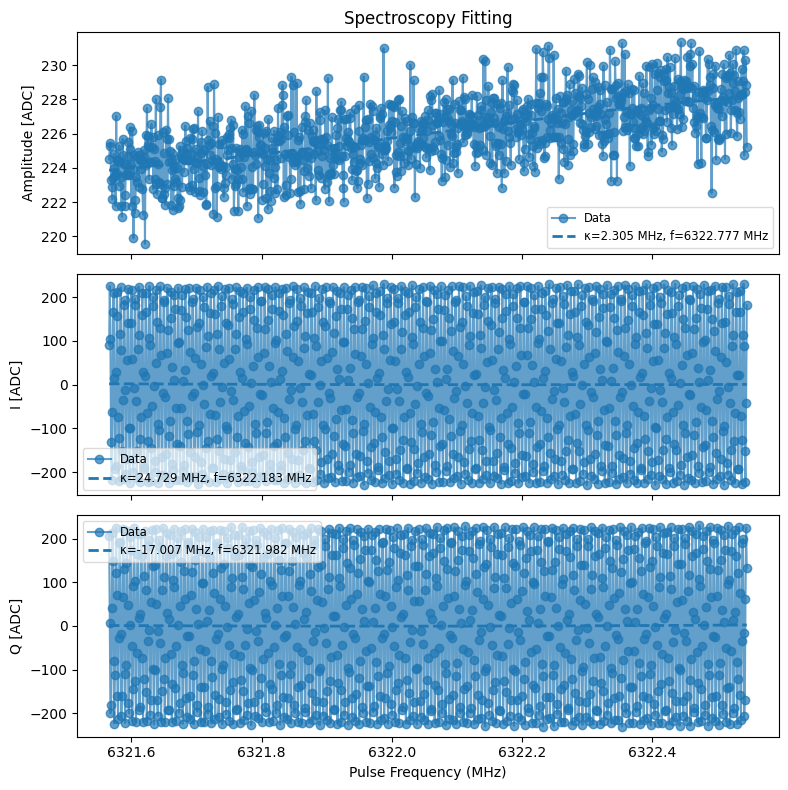

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-13_14-01-11_Spectroscopy_Fitting.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-13_14-01-11_Spectroscopy_Fitting.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-13.md


In [24]:
spec_analysis = meas.SpectroscopyFitting(#title='Readout Spectroscopy',
                                         data=rspec.data, station=station)
spec_analysis.analyze()
spec_analysis.display()

In [ ]:
rspec_wide = do_res_spec(
    config_thisrun                = config_thisrun,
    frequency                     = 7600.0,
    span                          = 30,
    expts                         = 300,
    reps                          = 100,
    rounds                        = 1,
    gain                          = 0.2,
    length                        = 3.0,
    final_delay                   = 250,
    pulse_e                       = False,
    prepulse                      = {},
    analyze_and_display           = True,
    use_config_params_for_readout = False,
)

In [ ]:
rspec_fine = do_res_spec(
    config_thisrun                = config_thisrun,
    frequency                     = 7600.391,   # <-- update from wide scan
    span                          = 3,
    expts                         = 300,
    reps                          = 400,
    rounds                        = 1,
    gain                          = 0.08,
    length                        = 3.0,
    final_delay                   = 250,
    pulse_e                       = False,
    prepulse                      = {},
    analyze_and_display           = True,
    use_config_params_for_readout = False,
)

In [ ]:
update_res_spec(
    rspec          = rspec_fine,
    config_thisrun = config_thisrun,
)

In [ ]:
# High power punchout check
rspec_highp = do_res_spec(
    config_thisrun                = config_thisrun,
    frequency                     = config_thisrun.device.readout.frequency,
    span                          = 5,
    expts                         = 300,
    reps                          = 100,
    rounds                        = 1,
    gain                          = 1.0,
    length                        = 3.0,
    final_delay                   = 250,
    pulse_e                       = False,
    prepulse                      = {},
    analyze_and_display           = True,
    use_config_params_for_readout = False,
)

## Chi to Qubit

connected proxies, ns= <Pyro4.core.Proxy at 0x1db99b52090; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  frequency
param values:  {'label': 'readout_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 7596.919829610536, 'step': 0.023333333333333334, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': <qick.asm_v2.QickParam object at 0x000001DB94092AD0>, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/150000 [00:00<?, ?it/s]

Saving S:\Multimode\experiment\2600403_lmm\data\00345_ResonatorSpectroscopyExperiment.h5
connected proxies, ns= <Pyro4.core.Proxy at 0x1db99b52990; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  frequency
param values:  {'label': 'readout_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 7596.919829610536, 'step': 0.023333333333333334, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': <qick.asm_v2.QickParam object at 0x000001DB99C1B850>, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/150000 [00:00<?, ?it/s]

Saving S:\Multimode\experiment\2600403_lmm\data\00346_ResonatorSpectroscopyExperiment.h5
new display function for spectroscopy
Data 1 - Found peak in amps at 7600.396 MHz, HWHM 0.623
Data 2 - Found peak in amps at 7599.754 MHz, HWHM 2.951
Data 1 - Found peak in avgi at 7600.572 MHz, HWHM -0.003
Data 2 - Found peak in avgi at 7600.390 MHz, HWHM 116.015
Data 1 - Found peak in avgq at 7601.836 MHz, HWHM 0.003
Data 2 - Found peak in avgq at 7598.825 MHz, HWHM 3.408


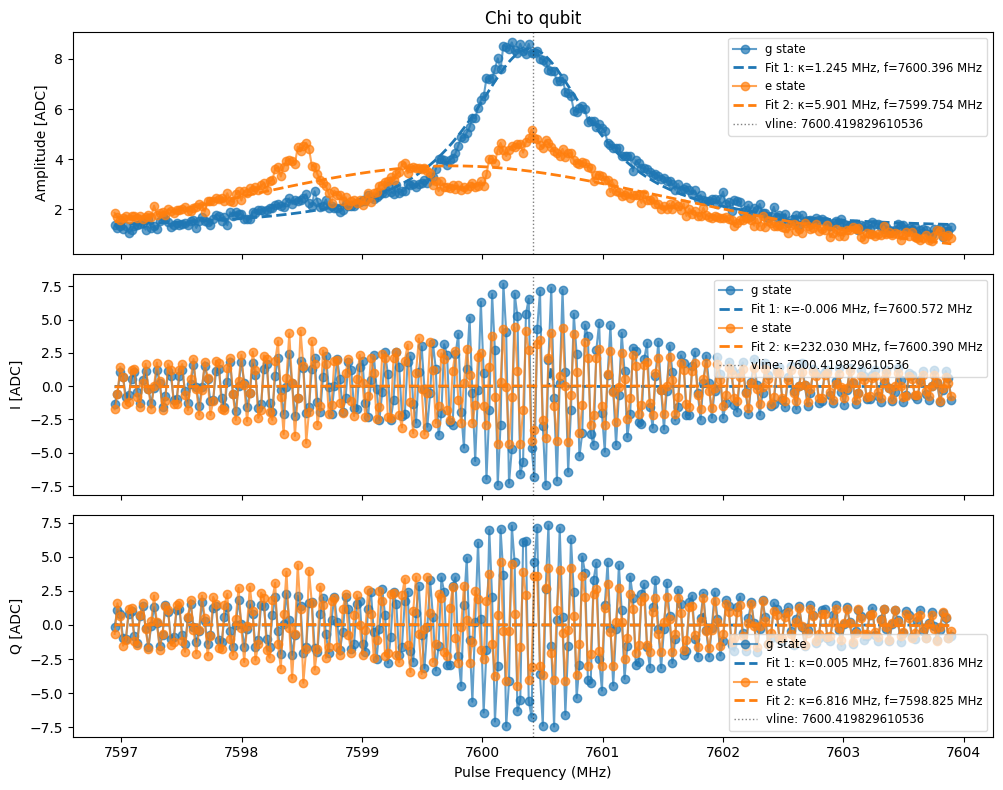

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_11-45-05_Chi_to_qubit.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_11-45-05_Chi_to_qubit.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-14.md
Chi_ge = -0.642 MHz


In [5]:
rspecs_chi = []
for pulse_e in [False, True]:
    rspec = do_res_spec(
        config_thisrun                = config_thisrun,
        frequency                     = config_thisrun.device.readout.frequency,
        span                          = 7,
        expts                         = 300,
        reps                          = 500,
        rounds                        = 1,
        gain                          = config_thisrun.device.readout.gain,
        length                        = config_thisrun.device.readout.length,
        final_delay                   = 250,
        pulse_e                       = pulse_e,
        prepulse                      = {},
        analyze_and_display           = False,
        use_config_params_for_readout = False,
    )
    rspecs_chi.append(rspec)

spec_analysis = meas.SpectroscopyFitting(data=rspecs_chi[0].data, station=station)
_ = spec_analysis.analyze(data_list=[x.data for x in rspecs_chi])
spec_analysis.display(
    data_list   = [x.data for x in rspecs_chi],
    data_labels = ['g state', 'e state'],
    title       = 'Chi to qubit',
    vlines      = [config_thisrun.device.readout.frequency],
    figsize     = (10, 8),
)
chi_ge = rspecs_chi[1].data['fit_amps'][2] - rspecs_chi[0].data['fit_amps'][2]
print(f'Chi_ge = {chi_ge:.3f} MHz')

## 2D Gain Sweep (Live Colorplot)

In [ ]:
gains      = np.logspace(-1, -4, 50)[::-1]
amp_matrix = None
freq_array = None
rspecs_2d  = []
peak_amps  = []

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
plt.ion()

for idx, gain in enumerate(gains):
    reps = min(int(100 * (1.0 / gain) ** 0.69897), 5000)
    print(f'[{idx+1}/{len(gains)}] gain={gain:.4f}, reps={reps}')

    rspec = do_res_spec(
        config_thisrun                = config_thisrun,
        frequency                     = config_thisrun.device.readout.frequency,
        span                          = 10,
        expts                         = 200,
        reps                          = reps,
        rounds                        = 1,
        gain                          = gain,
        length                        = config_thisrun.device.readout.length,
        final_delay                   = 250,
        pulse_e                       = False,
        prepulse                      = {},
        analyze_and_display           = False,
        use_config_params_for_readout = False,
    )
    rspecs_2d.append(rspec)

    xpts = rspec.data['xpts']
    amps = np.abs(np.array(rspec.data['avgi']) + 1j * np.array(rspec.data['avgq']))
    peak_amps.append(float(amps.max()))

    if amp_matrix is None:
        freq_array = xpts
        amp_matrix = np.full((len(gains), len(xpts)), np.nan)
    amp_matrix[idx] = amps

    axes[0].cla(); axes[1].cla()
    im = axes[0].pcolormesh(freq_array, gains[:idx+1], amp_matrix[:idx+1],
                            shading='auto', cmap='viridis')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Frequency (MHz)')
    axes[0].set_ylabel('Gain')
    axes[0].set_title(f'Res spec vs gain ({idx+1}/{len(gains)})')
    axes[1].loglog(gains[:idx+1], peak_amps, 'o-', color='C1')
    axes[1].set_xlabel('Gain')
    axes[1].set_ylabel('Peak amplitude')
    axes[1].grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    clear_output(wait=True)
    display(fig)

plt.ioff()
print('Gain sweep done.')

## Single Shot

connected proxies, ns= <Pyro4.core.Proxy at 0x2c38a8a2f90; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
Using readout: gain=0.30000000000000004, length=3, frequency=7600.419829610536
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': -70.4279874205774, 'gain': 0.30000000000000004, 'length': 3}
922
307.2
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/10000 [00:00<?, ?it/s]

pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': -70.4279874205774, 'gain': 0.30000000000000004, 'length': 3}
922
307.2
pulsing e
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/10000 [00:00<?, ?it/s]

Fidelity: 6.22%
Rotation Angle: 26.44 degrees
Threshold: -1.97
fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-12_13-06-43_histogram.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-12_13-06-43_histogram.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-12.md


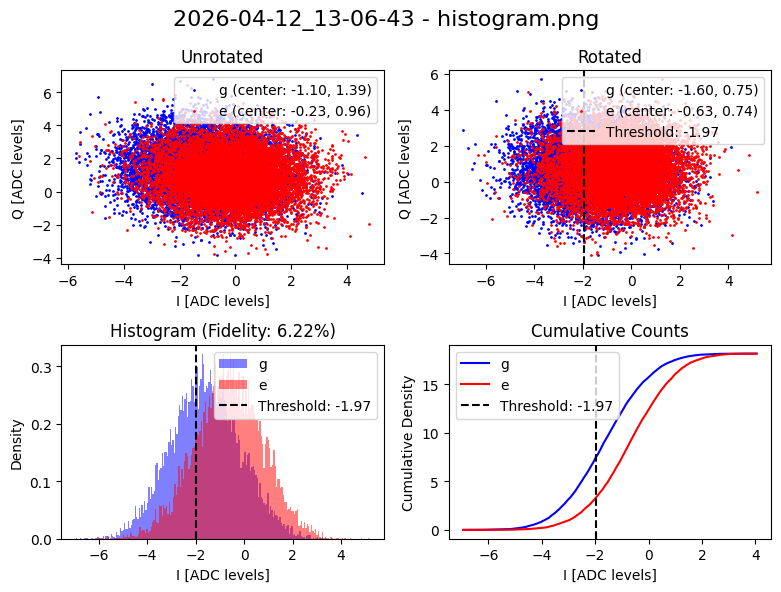

In [ ]:
hst = do_single_shot(
    config_thisrun       = config_thisrun,
    readout_gain         = config_thisrun.device.readout.gain,
    readout_length       = config_thisrun.device.readout.length,
    readout_frequency    =  config_thisrun.device.readout.frequency,
    shots                = 10000,
    pulse_e              = True,
    prepulse             = {},
    sweep_params         = {},
    final_delay          = 250,
    analyze_and_display  = True,
)

## Single Shot 2D Sweep (freq x gain)

connected proxies, ns= <Pyro4.core.Proxy at 0x2c38c4ec710; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
Using readout: gain=0.2, length=3, frequency=7600.419829610536
entering initialize sweep vars 
param name:  readout_frequency
param values:  {'label': 'readout_pulse', 'param': 'freq', 'param_type': 'pulse', 'expts': 30, 'start': 7598.919829610536, 'step': 0.1}
param name:  readout_gain
param values:  {'label': 'readout_pulse', 'param': 'gain', 'param_type': 'pulse', 'expts': 30, 'start': 0.0, 'step': 0.013333333333333334}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': <qick.asm_v2.QickParam object at 0x000002C38CA931D0>, 'phase': -70.4279874205774, 'gain': <qick.asm_v2.QickParam object at 0x000002C38CA92A50>, 'length': 3}
922
307.2
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/900000 [00:00<?, ?it/s]

pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': <qick.asm_v2.QickParam object at 0x000002C38CACEC50>, 'phase': -70.4279874205774, 'gain': <qick.asm_v2.QickParam object at 0x000002C38BD734D0>, 'length': 3}
922
307.2
pulsing e
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/900000 [00:00<?, ?it/s]

(np.int64(8), np.int64(14))


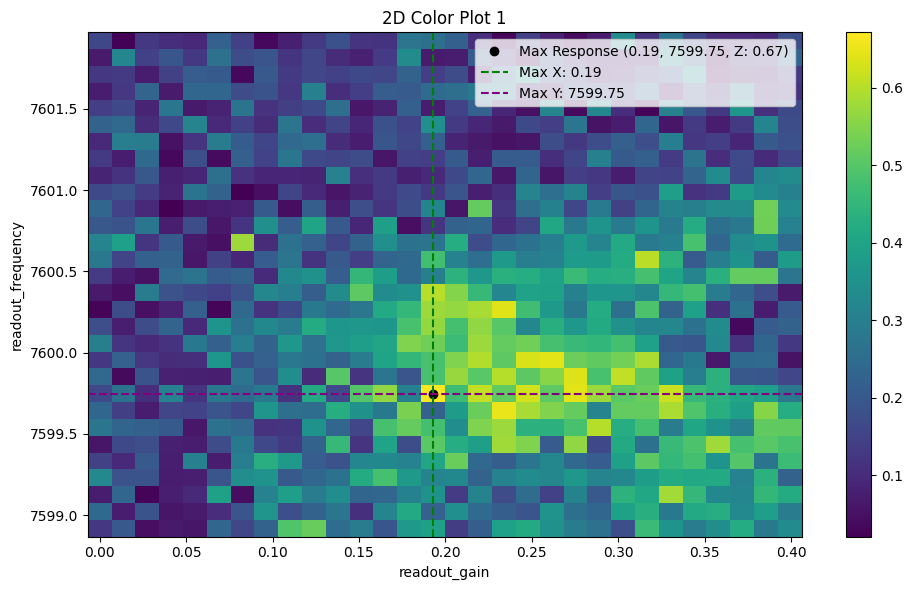

Optimal point: [{'z_index': 0, 'max_value': np.float64(0.6713506045956954), 'max_x': np.float64(0.19269974974058474), 'max_y': np.float64(7599.747309494018), 'x_idx': np.int64(14), 'y_idx': np.int64(8)}]


In [25]:
freq_span  = 3.0
gain_span  = 0.4
freq_expts = 30
gain_expts = 30

sweep_params_2d = {
    'readout_frequency': {
        'label':      'readout_pulse',
        'param':      'freq',
        'param_type': 'pulse',
        'expts':      freq_expts,
        'start':      config_thisrun.device.readout.frequency - freq_span / 2,
        'step':       freq_span / freq_expts,
    },
    'readout_gain': {
        'label':      'readout_pulse',
        'param':      'gain',
        'param_type': 'pulse',
        'expts':      gain_expts,
        'start':      config_thisrun.device.readout.gain - gain_span / 2,
        'step':       gain_span / gain_expts,
    },
}

hst_sweep = do_single_shot(
    config_thisrun       = config_thisrun,
    readout_gain         = config_thisrun.device.readout.gain,
    readout_length       = config_thisrun.device.readout.length,
    readout_frequency    = config_thisrun.device.readout.frequency,
    shots                = 1000,
    pulse_e              = True,
    prepulse             = {},
    sweep_params         = sweep_params_2d,
    final_delay          = 250,
    analyze_and_display  = False,
)

hst_analysis = meas.Histogram(
    hst_sweep.data,
    station      = station,
    sweep_params = sweep_params_2d,
)
_ = hst_analysis.analyze_swept_histogram_data()
plot_obj = hst_analysis.display_swept_histogram_data()
print('Optimal point:', plot_obj.results)

In [ ]:
# Uncomment to apply optimal readout point from sweep
# config_thisrun.device.readout.frequency = float(plot_obj.results[0]['max_y'])
# config_thisrun.device.readout.gain      = float(plot_obj.results[0]['max_x'])

In [ ]:
update_single_shot(
    hst_analysis   = hst,
    config_thisrun = config_thisrun,
)

In [ ]:
station.handle_config_update(write_to_file=True)
print('Config saved.')

## YOKO Current Sweep

In [11]:
from yoko_current_sweep import * 
dcflux = connect_yoko(address='10.108.30.37')
print(f'Current: {dcflux.get_current()*1e3:.4f} mA')


Connected to Yokogawa at 10.108.30.37
Current output: 0.0000 mA
Current: 0.0000 mA


#### Res Spec

In [ ]:

def do_yoko_res_sweep(
    config_thisrun,
    dcflux,
    # current sweep params
    current_start_mA  = -0.12,
    current_stop_mA   =  0.12,
    current_step_mA   =  0.003,
    # res spec params (per current point)
    frequency         = 7600.0,    # MHz, center
    span              = 10.0,       # MHz
    expts             = 200,       # frequency points
    reps              = 300,
    rounds            = 1,
    gain              = 0.2,
    length            = 3.0,       # us
    final_delay       = 250,
    # display
    plot_key          = 'amps',    # 'amps' | 'avgi' | 'avgq'
    cmap              = 'RdBu_r',
    figsize           = (14, 10),
    # safety
    ramp_to_start     = True,      # ramp slowly to start current before sweep
    ramp_steps        = 20,
    ramp_delay_s      = 0.05,
    settle_delay_s    = 0.1,       # wait after each current step before measuring
):
    """
    Sweep Yokogawa DC current and measure resonator spectroscopy at each point.
    Shows a live 2D colorplot (current vs frequency) updating after each step.

    Parameters
    ----------
    config_thisrun    : AttrDict — experiment config
    dcflux            : YokogawaGS200 — connected Yoko object (from connect_yoko)
    current_start_mA  : float — sweep start [mA]
    current_stop_mA   : float — sweep stop [mA]
    current_step_mA   : float — step size [mA]
    frequency         : float — res spec center frequency [MHz]
    span              : float — res spec frequency span [MHz]
    expts             : int   — number of frequency points per res spec
    reps              : int   — averages per frequency point
    rounds            : int   — software rounds
    gain              : float — readout gain
    length            : float — readout pulse length [us]
    final_delay       : int   — delay after sequence [us]
    plot_key          : str   — which signal to plot: 'amps', 'avgi', 'avgq'
    cmap              : str   — matplotlib colormap
    figsize           : tuple — figure size
    ramp_to_start     : bool  — if True, ramp slowly to current_start_mA first
    ramp_steps        : int   — number of steps for initial ramp
    ramp_delay_s      : float — delay per ramp step [s]
    settle_delay_s    : float — settle time after each current step [s]

    Returns
    -------
    dict with keys:
        'currents'   : np.ndarray of current values [mA]
        'freq_array' : np.ndarray of frequency points [MHz]
        'amp_matrix' : 2D np.ndarray (n_currents x n_freqs)
        'rspecs'     : list of raw rspec experiment objects
    """
    import time
    from calibration_helpers import do_res_spec

    currents = np.arange(current_start_mA, current_stop_mA, current_step_mA)
    n_steps  = len(currents)
    print(f'Sweep: {current_start_mA:.4f} → {current_stop_mA:.4f} mA, '
          f'step={current_step_mA:.4f} mA, n={n_steps}')
    print(f'Estimated time: ~{n_steps * reps * expts / 1000:.1f} min (rough)')

    # ramp to start safely
    if ramp_to_start:
        ramp_current_mA(
            dcflux     = dcflux,
            target_mA  = current_start_mA,
            n_steps    = ramp_steps,
            delay_s    = ramp_delay_s,
        )

    amp_matrix = None
    freq_array = None
    rspecs     = []

    # set up live figure
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    plt.ion()
    cbar = None

    try:
        for idx, cur_mA in enumerate(currents):
            # set current
            set_current_mA(dcflux, cur_mA)
            time.sleep(settle_delay_s)

            print(f'[{idx+1}/{n_steps}]  current = {cur_mA:.4f} mA')

            rspec = do_res_spec(
                config_thisrun                = config_thisrun,
                frequency                     = frequency,
                span                          = span,
                expts                         = expts,
                reps                          = reps,
                rounds                        = rounds,
                gain                          = gain,
                length                        = length,
                final_delay                   = final_delay,
                pulse_e                       = False,
                prepulse                      = {},
                analyze_and_display           = False,
                use_config_params_for_readout = False,
            )
            rspecs.append(rspec)

            xpts = rspec.data['xpts']
            row  = np.array(rspec.data[plot_key])
            if row.ndim > 1:
                row = row.flatten()

            if amp_matrix is None:
                freq_array = xpts
                amp_matrix = np.full((n_steps, len(xpts)), np.nan)
            amp_matrix[idx] = row

            # ── live plot ────────────────────────────────────────
            axes[0].cla()
            axes[1].cla()

            filled = idx + 1
            im = axes[0].pcolormesh(
                freq_array,
                currents[:filled] * 1e3,   # show in uA for readability if small
                amp_matrix[:filled],
                shading = 'auto',
                cmap    = cmap,
            )
            axes[0].set_xlabel('Frequency (MHz)', fontsize=12)
            axes[0].set_ylabel('DC Current (muA)', fontsize=12)
            axes[0].set_title(
                f'Res spec vs Yoko current [{plot_key}]  '
                f'({filled}/{n_steps})  |  center={frequency} MHz',
                fontsize=12,
            )
            if cbar is None:
                cbar = fig.colorbar(im, ax=axes[0], label=plot_key)
            else:
                cbar.update_normal(im)

            # bottom panel: peak frequency vs current
            peak_freqs = [
                rspecs[i].data['xpts'][np.argmax(np.abs(np.array(rspecs[i].data[plot_key])))]
                for i in range(filled)
            ]
            axes[1].plot(currents[:filled] * 1e3, peak_freqs, 'o-', color='C1', ms=4)
            axes[1].set_xlabel('DC Current (mA)', fontsize=12)
            axes[1].set_ylabel('Peak frequency (MHz)', fontsize=12)
            axes[1].set_title('Peak frequency vs current', fontsize=12)
            axes[1].grid(True, alpha=0.3)

            fig.tight_layout()
            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print('\nSweep interrupted by user.')

    finally:
        # always turn off output when done or interrupted
        dcflux.set_output(False)
        print('Yoko output OFF.')

    plt.ioff()
    print(f'\nSweep complete. {len(rspecs)}/{n_steps} points acquired.')

    return {
        'currents'   : currents[:len(rspecs)],
        'freq_array' : freq_array,
        'amp_matrix' : amp_matrix[:len(rspecs)] if amp_matrix is not None else None,
        'rspecs'     : rspecs,
    }


In [5]:
# ── connect ───────────────────────────────────────────────────
dcflux = connect_yoko(address='10.108.30.37')
print(f'Current: {dcflux.get_current()*1e3:.4f} mA')



Connected to Yokogawa at 10.108.30.37
Current output: 0.0850 mA
Current: 0.0850 mA


In [ ]:
# set_current_mA(dcflux, 0.001)

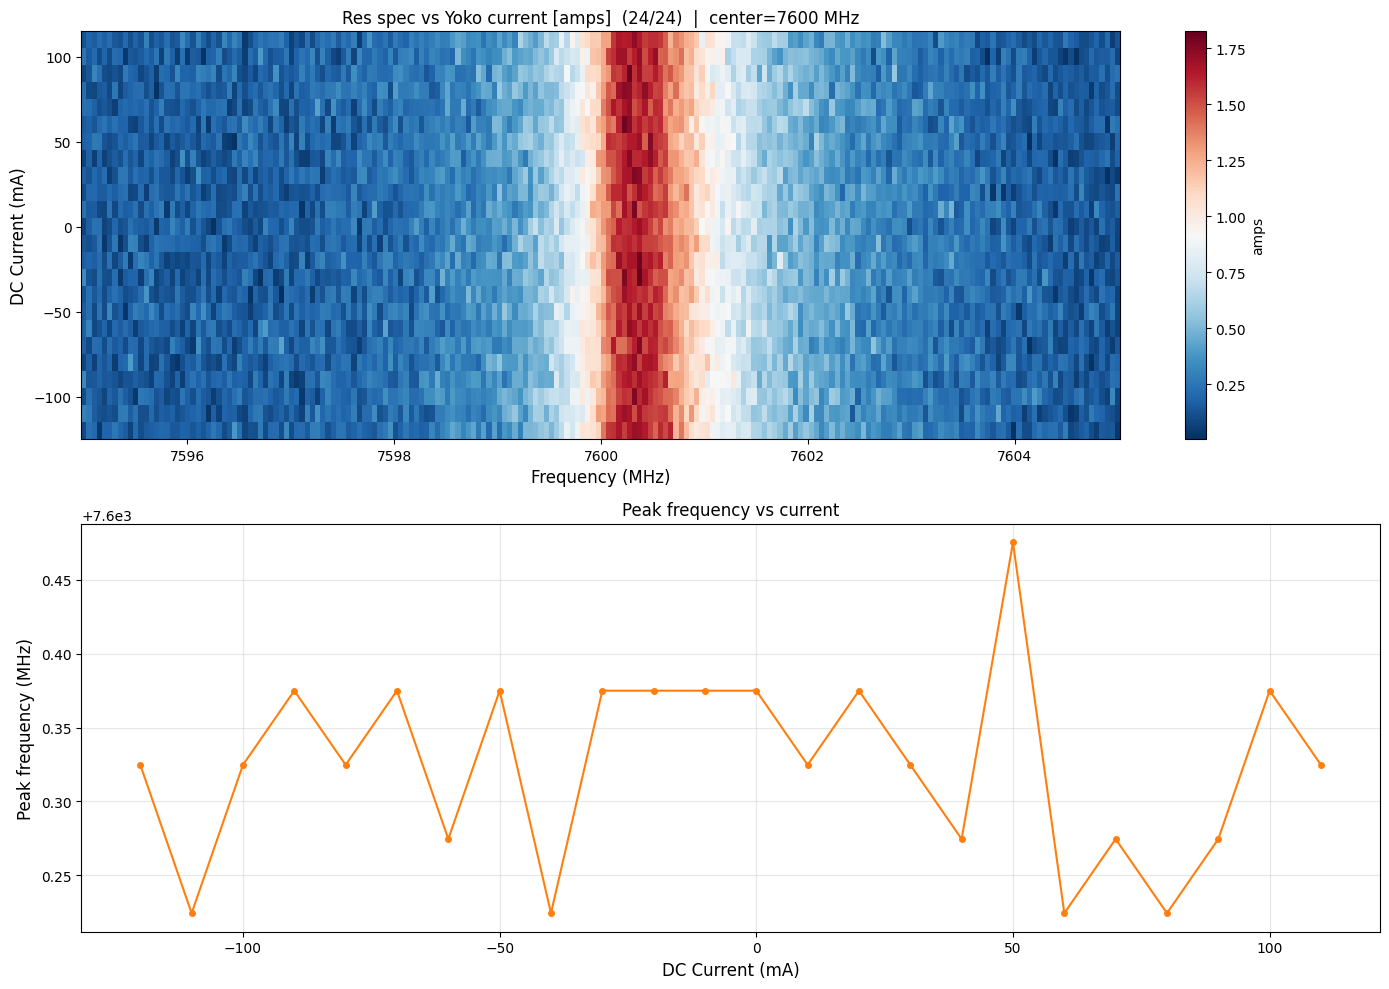

Yoko output OFF.

Sweep complete. 24/24 points acquired.


In [8]:
# ── run sweep ─────────────────────────────────────────────────
result = do_yoko_res_sweep(
    config_thisrun   = config_thisrun,
    dcflux           = dcflux,
    current_start_mA = -0.12,
    current_stop_mA  =  0.12,
    current_step_mA  =  0.01,
    frequency        = 7600,
    span             = 10.0,
    expts            = 200,
    reps             = 300,
    gain             = 0.2,
    length           = 3.0,
    final_delay      = 250,
    plot_key         = 'amps',
    ramp_to_start    = True,
)



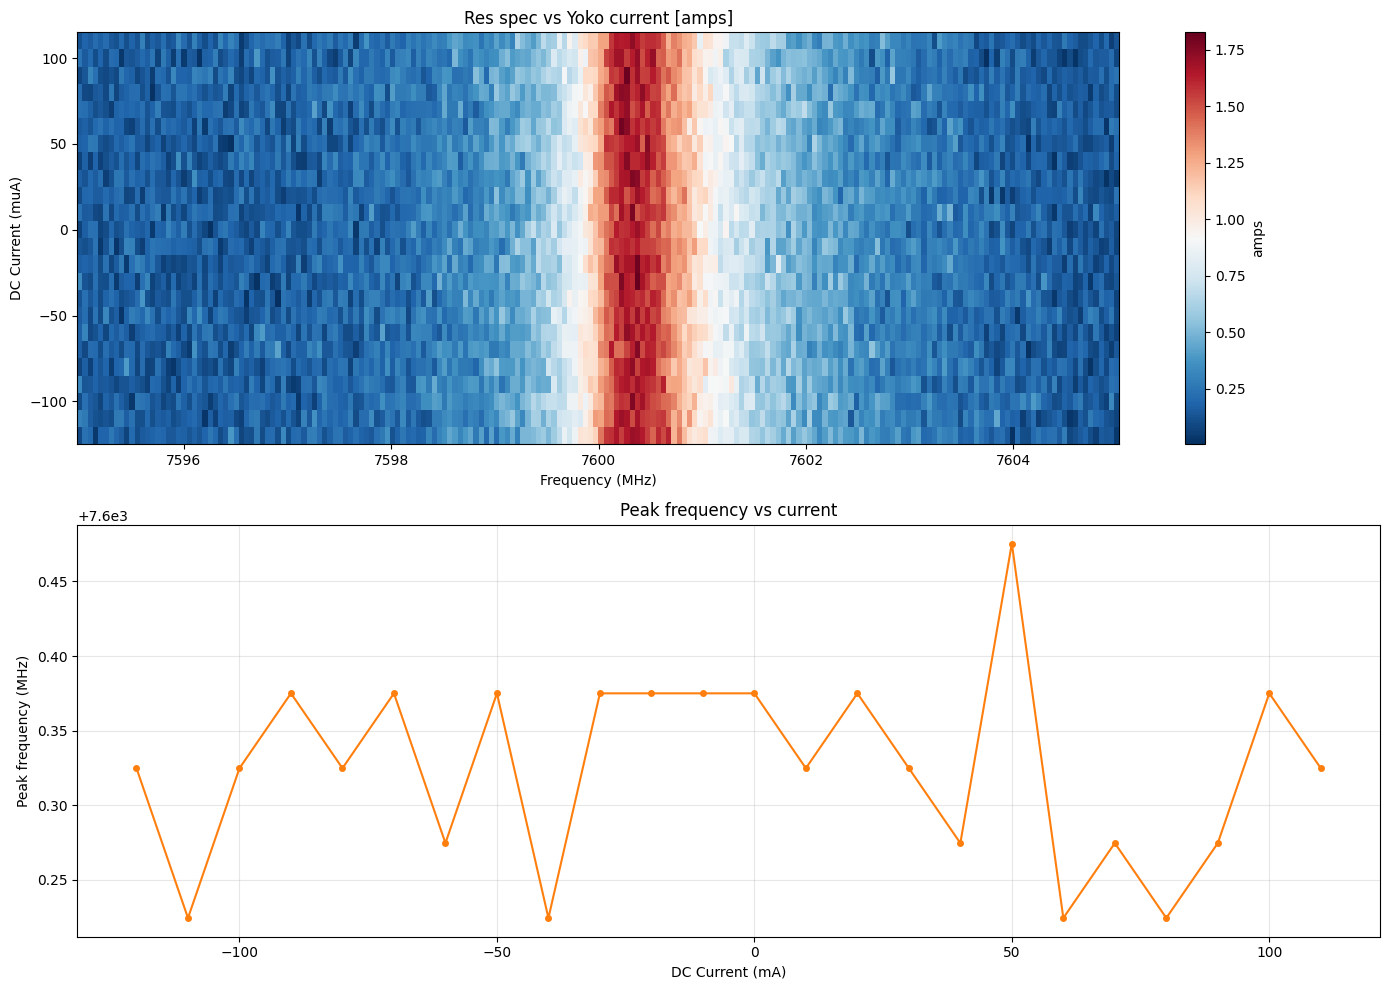

In [11]:
# ── replot with adjusted colorscale after the fact ────────────
_ = replot_yoko_sweep(result, plot_key='amps')

### Parity Spectroscopy

#### Man 1 Two Tone

In [ ]:
config_thisrun.hw.soc.dacs.manipulate_in.fc = 3800
config_thisrun.hw.soc.dacs.manipulate_in.att = [1,0]
station.handle_config_update(True)

Comparing configurations:
Key 'hw.soc.dacs.manipulate_in.fc' differs:
  Old value (config1): 4800
  New value (config2): 3800
Configuration updated and saved, excluding storage_man_file.


In [29]:
ramp_current_mA(dcflux, -0.00)
dcflux.set_output(True)

Ramped to -0.0000 mA


In [24]:
from calibration_helpers import do_pulse_probe_spec
parspec =  do_pulse_probe_spec(
    config_thisrun,
    center= 3704.0,
    span=40,
    expts=100,
    reps=300,
    rounds=1,
    prepulse= {},#{"hpi_qubit_ge":{}},  # should be a dict
    postpulse= {},#{"hpi_qubit_ge":{},},  # should be a dict
    
    
    probe_pulse_param = {
    "gain": 0.05, #0.123,
    "length": 0.1, #0.2
    "freq": None,  # doesn't matter
    "chan": 0, #config_thisrun.hw.soc.dacs.qubit.ch,
    "sigma": 0,
    "sigma_inc": 0,
    "ramp_sigma": None,
    "ramp_sigma_inc": None,
    "phase":0,
    "type": 'const',
    "t":0},
    analyze_and_display = False
)

connected proxies, ns= <Pyro4.core.Proxy at 0x1d47cbf0290; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 3684.0, 'step': 0.4, 'expts': 100, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.397, 'phase': -70.4279874205774, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': 0.05, 'length': 0.1, 'freq': <qick.asm_v2.QickParam object at 0x000001D47C424250>, 'chan': 0, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const', 't': 0}
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/30000 [00:00<?, ?it/s]

new display function for spectroscopy
Data 1 - Found peak in amps at 3704.572 MHz, HWHM 4.692
Data 1 - Found peak in avgi at 3704.590 MHz, HWHM 4.736
Data 1 - Found peak in avgq at 3704.230 MHz, HWHM 3.617


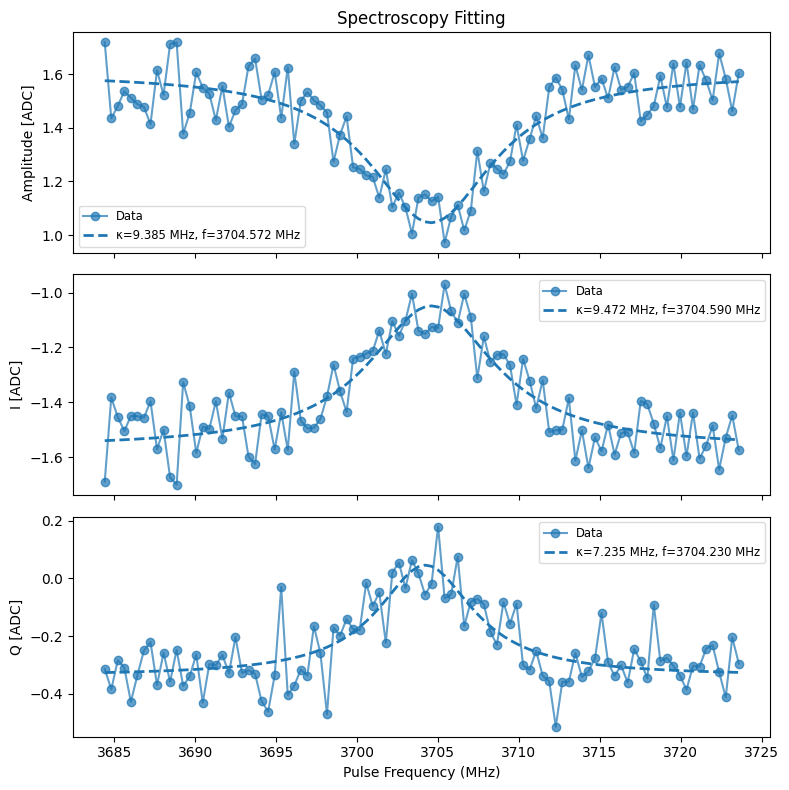

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-10_10-03-10_Spectroscopy_Fitting.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-10_10-03-10_Spectroscopy_Fitting.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-10.md


In [25]:
spec_analysis = meas.SpectroscopyFitting(station = station, data=parspec.data)
spec_analysis.analyze() #fitparams = [-0.7, -0.5, 3064.7, 10]) #[y0, yscale, x0, xscale]
spec_analysis.display()

In [27]:
def do_yoko_parity_sweep(
    config_thisrun,
    dcflux,
    # current sweep params
    current_start_mA  = -0.22,
    current_stop_mA   =  0.05,
    current_step_mA   =  0.003,
    # parity spec params (per current point)
    center            = 4792.0,    # MHz
    span              = 100.0,     # MHz
    expts             = 400,
    reps              = 100,
    rounds            = 1,
    probe_gain        = 0.5,
    probe_length      = 0.2,       # us
    probe_chan        = 2,         # manipulate channel
    prepulse          = {},
    postpulse         = {},
    # display
    plot_key          = 'avgi',    # 'amps' | 'avgi' | 'avgq'
    cmap              = 'RdBu_r',
    figsize           = (14, 10),
    # safety
    ramp_to_start     = True,
    ramp_steps        = 20,
    ramp_delay_s      = 0.05,
    settle_delay_s    = 0.1,
):
    """
    Sweep Yokogawa DC current and measure parity spectroscopy at each point.
    Uses do_pulse_probe_spec on the manipulate channel (chan=2) around
    the manipulate frequency.

    Parameters
    ----------
    config_thisrun   : AttrDict
    dcflux           : YokogawaGS200
    current_start_mA : float — sweep start [mA]
    current_stop_mA  : float — sweep stop [mA]
    current_step_mA  : float — step size [mA]
    center           : float — probe center frequency [MHz]
    span             : float — probe frequency span [MHz]
    expts            : int   — frequency points per spec
    reps             : int   — averages per point
    rounds           : int   — software rounds
    probe_gain       : float — probe pulse gain
    probe_length     : float — probe pulse length [us]
    probe_chan       : int   — DAC channel (2 = manipulate)
    prepulse         : dict  — prepulse dict
    postpulse        : dict  — postpulse dict
    plot_key         : str   — 'amps', 'avgi', 'avgq'
    cmap             : str   — matplotlib colormap
    figsize          : tuple
    ramp_to_start    : bool
    ramp_steps       : int
    ramp_delay_s     : float
    settle_delay_s   : float

    Returns
    -------
    dict with keys:
        'currents'   : np.ndarray [mA]
        'freq_array' : np.ndarray [MHz]
        'amp_matrix' : 2D np.ndarray (n_currents x n_freqs)
        'pspecs'     : list of raw ppspec experiment objects
    """
    import time
    from calibration_helpers import do_pulse_probe_spec

    currents = np.arange(current_start_mA, current_stop_mA, current_step_mA)
    n_steps  = len(currents)
    print(f'Parity sweep: {current_start_mA:.4f} → {current_stop_mA:.4f} mA, '
          f'step={current_step_mA:.4f} mA, n={n_steps}')

    if ramp_to_start:
        ramp_current_mA(
            dcflux    = dcflux,
            target_mA = current_start_mA,
            n_steps   = ramp_steps,
            delay_s   = ramp_delay_s,
        )

    amp_matrix = None
    freq_array = None
    pspecs     = []

    fig, axes = plt.subplots(2, 1, figsize=figsize)
    plt.ion()
    cbar = None

    try:
        for idx, cur_mA in enumerate(currents):
            set_current_mA(dcflux, cur_mA)
            time.sleep(settle_delay_s)
            print(f'[{idx+1}/{n_steps}]  current = {cur_mA:.4f} mA')

            pspec = do_pulse_probe_spec(
                config_thisrun      = config_thisrun,
                center              = center,
                span                = span,
                expts               = expts,
                reps                = reps,
                rounds              = rounds,
                pulse_e             = False,
                prepulse            = prepulse,
                postpulse           = postpulse,
                sweep_other_param   = None,
                probe_pulse_param   = {
                    'gain':           probe_gain,
                    'length':         probe_length,
                    'freq':           None,
                    'chan':           probe_chan,
                    'sigma':          0,
                    'sigma_inc':      0,
                    'ramp_sigma':     None,
                    'ramp_sigma_inc': None,
                    'phase':          0,
                    'type':           'const',
                },
                analyze_and_display = False,
            )
            pspecs.append(pspec)

            xpts = pspec.data['xpts']
            row  = np.array(pspec.data[plot_key])
            if row.ndim > 1:
                row = row.flatten()

            if amp_matrix is None:
                freq_array = xpts
                amp_matrix = np.full((n_steps, len(xpts)), np.nan)
            amp_matrix[idx] = row

            # ── live plot ────────────────────────────────────────
            axes[0].cla()
            axes[1].cla()

            filled = idx + 1
            im = axes[0].pcolormesh(
                freq_array,
                currents[:filled],
                amp_matrix[:filled],
                shading = 'auto',
                cmap    = cmap,
            )
            axes[0].set_xlabel('Frequency (MHz)', fontsize=12)
            axes[0].set_ylabel('DC Current (mA)', fontsize=12)
            axes[0].set_title(
                f'Parity spec vs Yoko current [{plot_key}]  '
                f'({filled}/{n_steps})  |  center={center} MHz',
                fontsize=12,
            )
            if cbar is None:
                cbar = fig.colorbar(im, ax=axes[0], label=plot_key)
            else:
                cbar.update_normal(im)

            # bottom: peak frequency vs current
            peak_freqs = [
                pspecs[i].data['xpts'][np.argmax(np.abs(np.array(pspecs[i].data[plot_key])))]
                for i in range(filled)
            ]
            axes[1].plot(currents[:filled], peak_freqs, 'o-', color='C2', ms=4)
            axes[1].set_xlabel('DC Current (mA)', fontsize=12)
            axes[1].set_ylabel('Peak frequency (MHz)', fontsize=12)
            axes[1].set_title('Peak frequency vs current', fontsize=12)
            axes[1].grid(True, alpha=0.3)

            fig.tight_layout()
            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print('\nSweep interrupted by user.')

    finally:
        dcflux.set_output(False)
        print('Yoko output OFF.')

    plt.ioff()
    print(f'\nSweep complete. {len(pspecs)}/{n_steps} points acquired.')

    return {
        'currents'   : currents[:len(pspecs)],
        'freq_array' : freq_array,
        'amp_matrix' : amp_matrix[:len(pspecs)] if amp_matrix is not None else None,
        'pspecs'     : pspecs,
    }

#### 

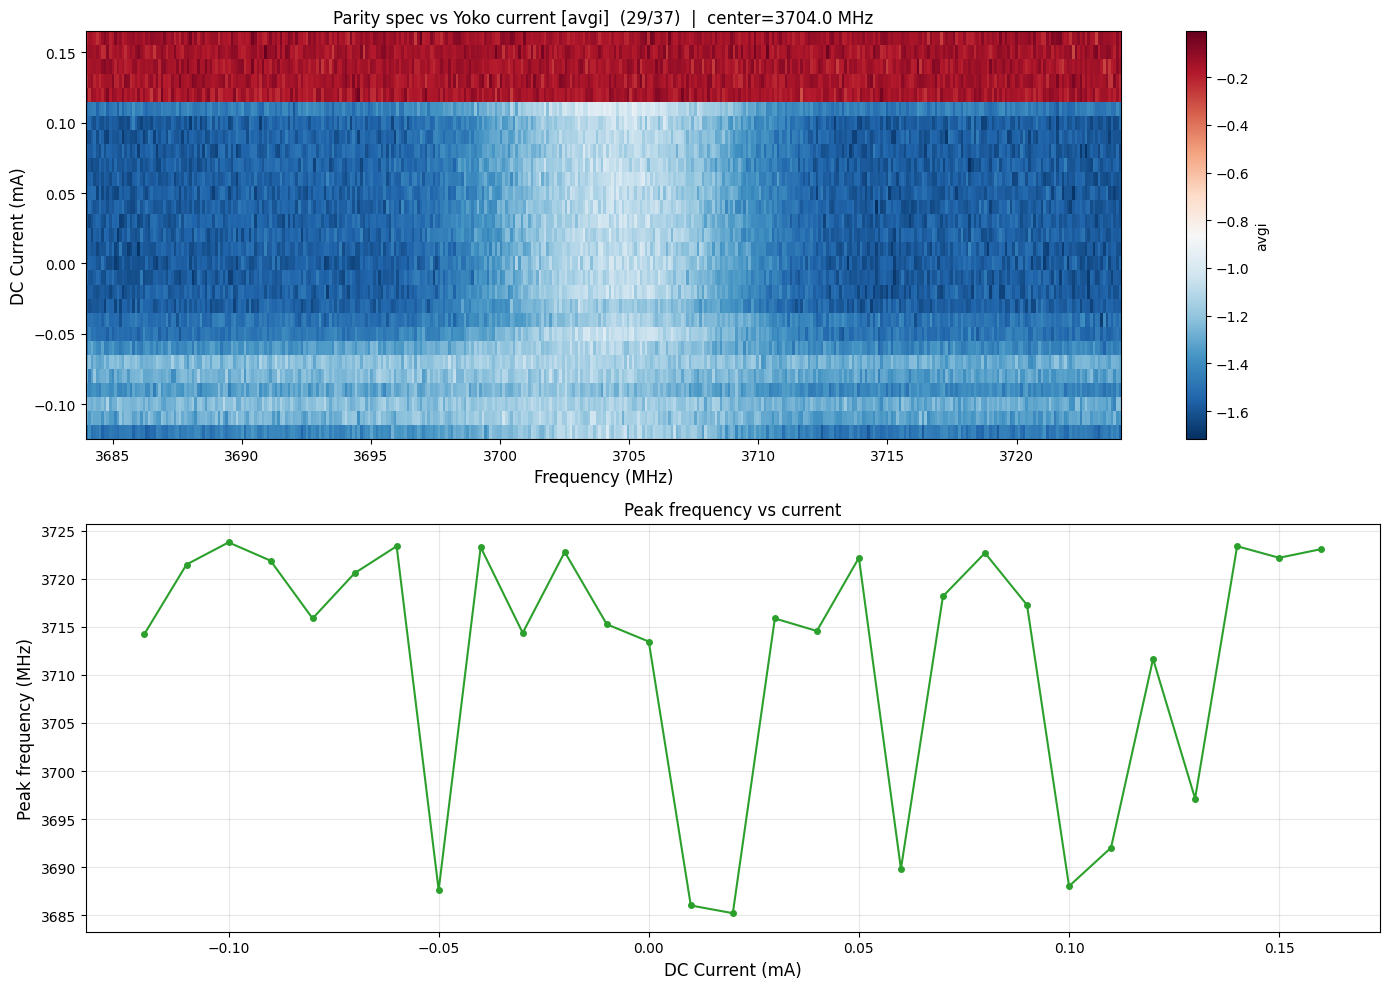

[30/37]  current = 0.1700 mA

Sweep interrupted by user.
Yoko output OFF.

Sweep complete. 29/37 points acquired.


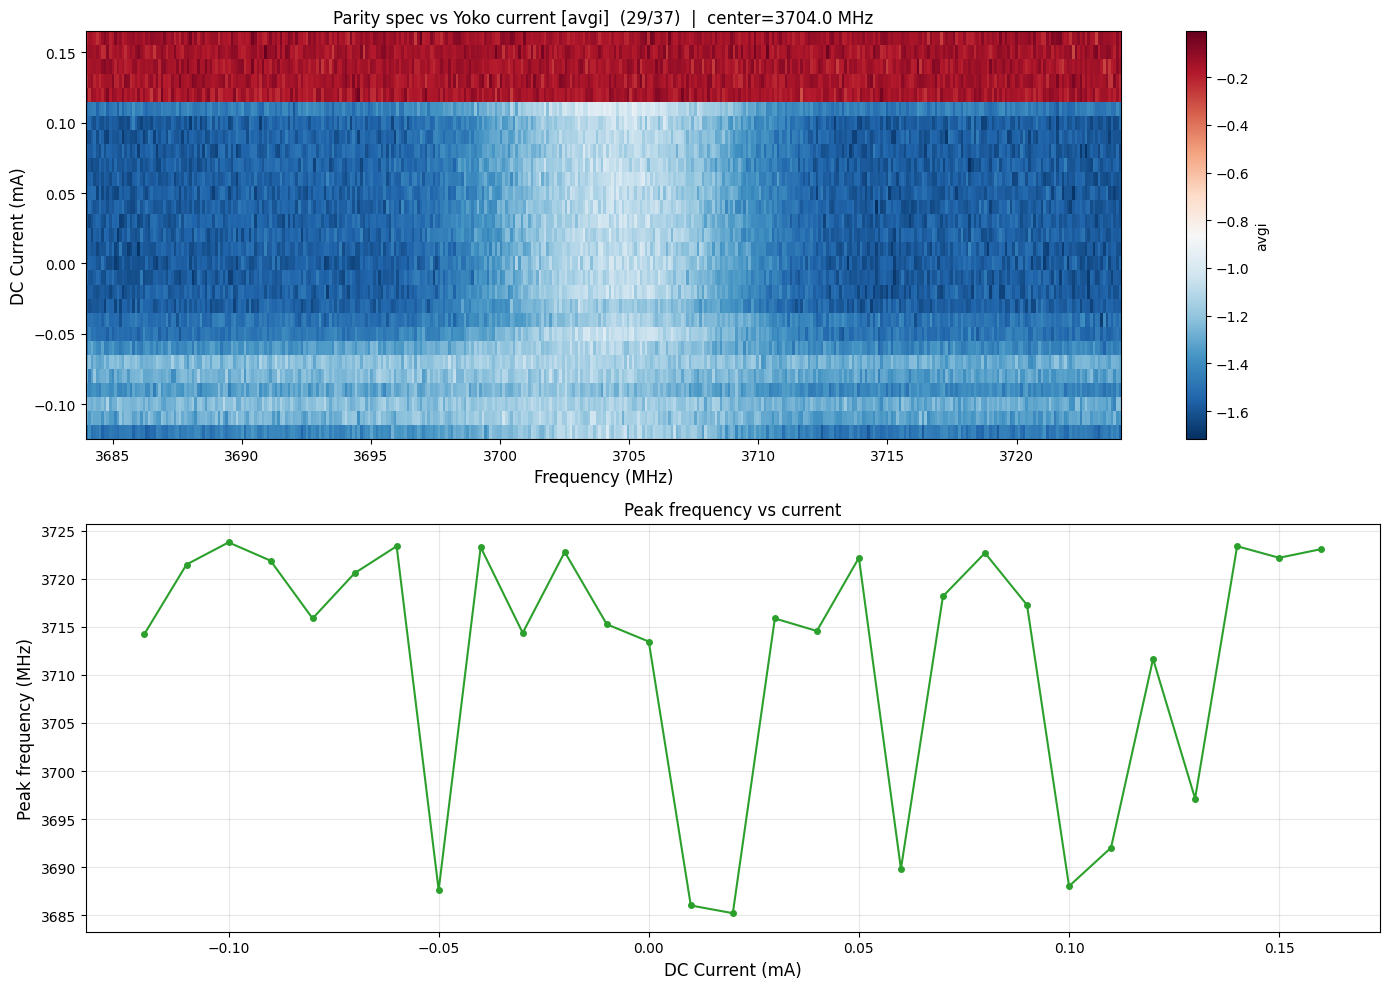

In [28]:
dcflux = connect_yoko(address='10.108.30.37')

result = do_yoko_parity_sweep(
    config_thisrun   = config_thisrun,
    dcflux           = dcflux,
    current_start_mA = -0.12,
    current_stop_mA  =  0.25,
    current_step_mA  =  0.01,
    center           = 3704.0,
    span             = 40.0,
    expts            = 400,
    reps             = 1000,
    probe_gain       = 0.05,
    probe_length     = 0.1,
    probe_chan       = 0,           # manipulate channel
    prepulse         = {},
    postpulse        = {},
    plot_key         = 'avgi',
    ramp_to_start    = True,
)